## **Phase 3: Stochastic Extreme Scenario Generation**

Because the Phase 2 Machine Learning benchmark demonstrated that historical daily satellite data cannot resolve sub-hourly extremes, this phase shifts the framework to scenario-based vulnerability testing.

#### **Scientific Methodology**

**1. True Calendar-Year Annual Maximum Series (AMS)**
To capture the most extreme hydro-meteorological events, the absolute maximum daily rainfall for each true calendar year was extracted from the 36-year continuous NASA POWER dataset. 

**2. Frequency Analysis (Gumbel Distribution)**
The Gumbel Extreme Value (Type I) distribution is a standard stochastic method in water resources engineering for modeling the maxima of natural phenomena. It was fitted to the AMS to calculate the theoretical 24-hour rainfall depths for 5-, 10-, 20-, and 50-year return periods, quantifying the probability of rare disasters.

**3. Temporal Disaggregation (Alternating Block Method)**
Urban flood severity is dictated by rainfall intensity, not just total volume. Because the calculated return periods are 24-hour totals, spreading them evenly would under-represent peak intensity. The Alternating Block Method was utilized to disaggregate the daily totals into synthetic hourly hyetographs. This method strategically forces the heaviest rainfall increments into the exact center of the storm, simulating a highly concentrated, worst-case tropical downpour.

--- Step 1: Extracting True Calendar-Year Annual Maximum Series (AMS) ---
Found date column: 'Date'. Extracting calendar years...
Successfully extracted 36 years of maximum rainfall data.

--- Step 2: Fitting Gumbel Distribution for Return Periods ---
Calculated 24-Hour Design Rainfall Depths:
  * 5-Year Storm: 69.38 mm/day
  * 10-Year Storm: 81.59 mm/day
  * 20-Year Storm: 93.30 mm/day
  * 50-Year Storm: 108.45 mm/day

--- Step 3: Generating Hourly Hyetographs (Alternating Block Method) ---
Saved TRUE calendar-year synthetic storms to: Hydrological/Design_Storm_Hyetographs.csv

--- Step 4: Generating Visualization ---
Saved visualization to: Hydrological/Design_Storms_IDF.png


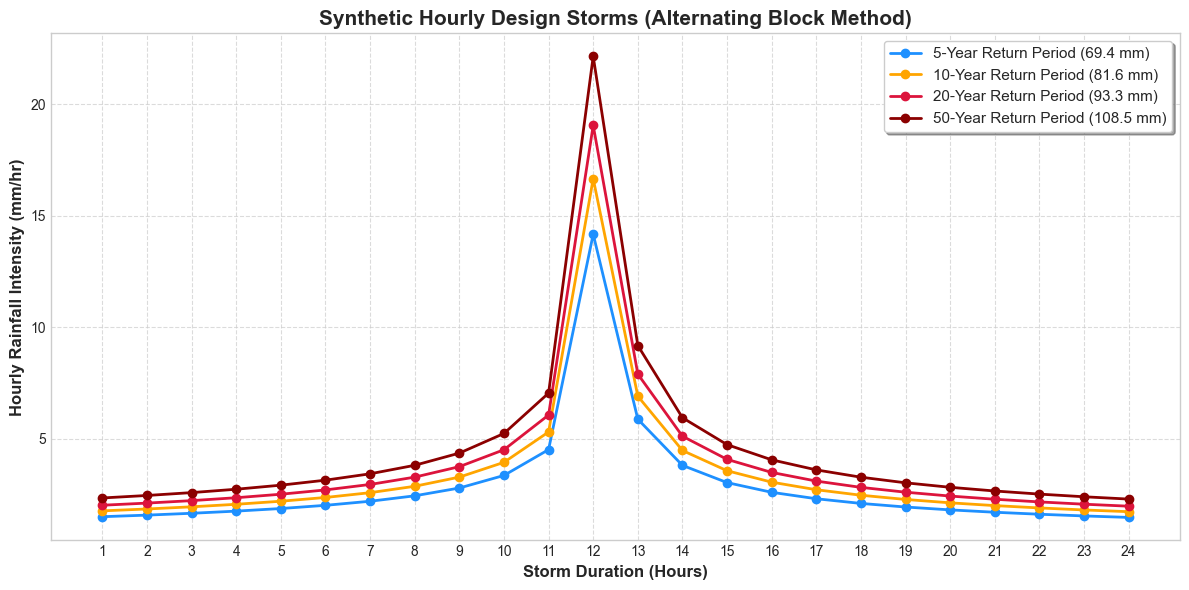

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r
import os

os.makedirs('Hydrological', exist_ok=True)

print("--- Step 1: Extracting True Calendar-Year Annual Maximum Series (AMS) ---")
df = pd.read_csv('Eleyele_HydroMet_Master.csv')

# THE FIX: Dynamically find the date column, regardless of capitalization
date_col = None
for col in df.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        date_col = col
        break

if date_col is not None:
    print(f"Found date column: '{date_col}'. Extracting calendar years...")
    df['Parsed_Date'] = pd.to_datetime(df[date_col], errors='coerce')
    df['Year'] = df['Parsed_Date'].dt.year
else:
    print("No explicit date column found. Falling back to 365.25-day chronological chunking...")
    # Fall back to chronological chunks, using 365.25 to safely account for leap years
    df['Year'] = (df.index / 365.25).astype(int)

df['PRECTOTCORR'] = pd.to_numeric(df['PRECTOTCORR'], errors='coerce')

# Group by the year, find max, drop NaNs
grouped_max = df.groupby('Year')['PRECTOTCORR'].max().dropna()
annual_max_rainfall = np.array(grouped_max.tolist(), dtype=float)

print(f"Successfully extracted {len(annual_max_rainfall)} years of maximum rainfall data.")

# Critical Safety Check
if len(annual_max_rainfall) < 2:
    raise ValueError("CRITICAL ERROR: Not enough years of data found to fit a distribution. "
                     f"Only {len(annual_max_rainfall)} year(s) detected. SciPy requires at least 2 points.")

print("\n--- Step 2: Fitting Gumbel Distribution for Return Periods ---")
# SciPy will now run perfectly because it has the correct array of multi-year data
loc, scale = gumbel_r.fit(annual_max_rainfall)

return_periods = [5, 10, 20, 50]
design_rainfall_24h = {}

print("Calculated 24-Hour Design Rainfall Depths:")
for T in return_periods:
    p = 1 - (1 / T)
    depth = gumbel_r.ppf(p, loc, scale)
    design_rainfall_24h[T] = depth
    print(f"  * {T}-Year Storm: {depth:.2f} mm/day")

# --- Step 3: IDF Temporal Disaggregation (Alternating Block Method) ---
print("\n--- Step 3: Generating Hourly Hyetographs (Alternating Block Method) ---")
hours = np.arange(1, 25)
synthetic_storms = pd.DataFrame({'Hour': hours})

def generate_alternating_block(total_depth):
    # Idealized cumulative rainfall curve
    cumulative_rain = total_depth * (hours / 24.0) ** 0.5 
    incremental_rain = np.diff(cumulative_rain, prepend=0)
    sorted_increments = np.sort(incremental_rain)[::-1]
    
    blocks = np.zeros(24)
    center = 11 
    for i, rain in enumerate(sorted_increments):
        if i == 0:
            blocks[center] = rain
        elif i % 2 == 1:
            if center + ((i + 1) // 2) < 24: blocks[center + ((i + 1) // 2)] = rain
        else:
            if center - (i // 2) >= 0: blocks[center - (i // 2)] = rain
    return blocks

for T in return_periods:
    synthetic_storms[f'{T}_yr_Rain_mm'] = generate_alternating_block(design_rainfall_24h[T])

synthetic_storms.to_csv('Hydrological/Design_Storm_Hyetographs.csv', index=False)
print("Saved TRUE calendar-year synthetic storms to: Hydrological/Design_Storm_Hyetographs.csv")

# =====================================================================
# --- Step 4: Publication-Ready Visualization ---
# =====================================================================
print("\n--- Step 4: Generating Visualization ---")
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))

colors = {5: 'dodgerblue', 10: 'orange', 20: 'crimson', 50: 'darkred'}

for T in return_periods:
    plt.plot(synthetic_storms['Hour'], synthetic_storms[f'{T}_yr_Rain_mm'], 
             marker='o', linewidth=2, label=f'{T}-Year Return Period ({design_rainfall_24h[T]:.1f} mm)', 
             color=colors[T])

plt.title('Synthetic Hourly Design Storms (Alternating Block Method)', fontsize=15, fontweight='bold')
plt.xlabel('Storm Duration (Hours)', fontsize=12, fontweight='bold')
plt.ylabel('Hourly Rainfall Intensity (mm/hr)', fontsize=12, fontweight='bold')
plt.xticks(np.arange(1, 25, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11, frameon=True, shadow=True)
plt.tight_layout()

plt.savefig('Hydrological/Design_Storms_IDF.png', dpi=300)
print("Saved visualization to: Hydrological/Design_Storms_IDF.png")